In [2]:
import tensorflow as tf

print("TensorFlow version:", tf.__version__)

TensorFlow version: 2.20.0


In [9]:
import os

print(os.listdir("/content"))

['.config', 'kaggle.json', 'sample_data']


In [11]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")
os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle configured successfully!")

Kaggle configured successfully!


In [12]:
!kaggle datasets download -d bilalakgz/brain-tumor-mri-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/bilalakgz/brain-tumor-mri-dataset
License(s): MIT
100% 92.1M/92.1M [00:01<00:00, 57.1MB/s]



In [13]:
import os

print(os.listdir("/content"))

['.config', 'brain-tumor-mri-dataset.zip', 'kaggle.json', 'sample_data']


In [14]:
import zipfile
import os

zip_path = "/content/brain-tumor-mri-dataset.zip"

print("File size:", os.path.getsize(zip_path), "bytes")

try:
    with zipfile.ZipFile(zip_path, "r") as z:
        print("ZIP is valid!")
        print("Number of files:", len(z.namelist()))
except zipfile.BadZipFile:
    print("ZIP is corrupted or incomplete.")

File size: 96541586 bytes
ZIP is valid!
Number of files: 3561


In [15]:
import zipfile
import os

zip_path = "/content/brain-tumor-mri-dataset.zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import zipfile

file_path = "/content/archive (2).zip"

try:
    with zipfile.ZipFile(file_path, "r") as z:
        print("ZIP opened successfully!")
        print("Number of files:", len(z.namelist()))
        print("First 10 files:")

        for file in z.namelist()[:10]:
            print(file)

        print("\nZIP test:", z.testzip())

except zipfile.BadZipFile:
    print("The ZIP file is incomplete or corrupted.")

The ZIP file is incomplete or corrupted.


In [ ]:
import os
import shutil

os.makedirs("/root/.kaggle", exist_ok=True)

shutil.copy("/content/kaggle.json", "/root/.kaggle/kaggle.json")

os.chmod("/root/.kaggle/kaggle.json", 0o600)

print("Kaggle API configured successfully!")

Kaggle API configured successfully!


In [ ]:
!kaggle datasets download -d bilalakgz/brain-tumor-mri-dataset -p /content

Dataset URL: https://www.kaggle.com/datasets/bilalakgz/brain-tumor-mri-dataset
License(s): MIT
100% 92.1M/92.1M [00:00<00:00, 110MB/s] 



In [ ]:
import os
import glob

files = glob.glob("/content/*.zip")

print("ZIP files found:")
for file in files:
    print(file, "→", os.path.getsize(file), "bytes")

ZIP files found:
/content/brain-tumor-mri-dataset.zip → 96541586 bytes


In [ ]:
import zipfile
import os

zip_path = "/content/brain-tumor-mri-dataset.zip"
extract_path = "/content/brain_tumor_dataset"

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [ ]:
import os

dataset_path = "/content/brain_tumor_dataset"

for root, dirs, files in os.walk(dataset_path):
    level = root.replace(dataset_path, "").count(os.sep)
    indent = "    " * level
    print(f"{indent}{os.path.basename(root)}/")

    if level >= 2:
        continue

brain_tumor_dataset/
    brain_tumor_dataset/
        brain_tumor_classification/
            Training/
                no_tumor/
                glioma_tumor/
                pituitary_tumor/
                meningioma_tumor/
            Testing/
                no_tumor/
                glioma_tumor/
                pituitary_tumor/
                meningioma_tumor/
        brain_tumor_segmentation/
            train/
                images/
                labels/
            test/
                images/
                labels/
            valid/
                images/
                labels/


In [ ]:
import os

train_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Training"
test_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Testing"

print("Training folders:")
print(os.listdir(train_path))

print("\nTesting folders:")
print(os.listdir(test_path))

Training folders:
['no_tumor', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']

Testing folders:
['no_tumor', 'glioma_tumor', 'pituitary_tumor', 'meningioma_tumor']


In [ ]:
import os

classes = [
    "no_tumor",
    "glioma_tumor",
    "pituitary_tumor",
    "meningioma_tumor"
]

print("TRAINING DATA")
print("-" * 30)

for class_name in classes:
    folder = os.path.join(train_path, class_name)
    count = len(os.listdir(folder))
    print(f"{class_name}: {count}")

print("\nTESTING DATA")
print("-" * 30)

for class_name in classes:
    folder = os.path.join(test_path, class_name)
    count = len(os.listdir(folder))
    print(f"{class_name}: {count}")

TRAINING DATA
------------------------------
no_tumor: 395
glioma_tumor: 826
pituitary_tumor: 827
meningioma_tumor: 822

TESTING DATA
------------------------------
no_tumor: 105
glioma_tumor: 100
pituitary_tumor: 74
meningioma_tumor: 115


In [ ]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [18]:
print("Class mapping:")
print(train_generator.class_indices)

Class mapping:
{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [17]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(rescale=1./255)
test_datagen = ImageDataGenerator(rescale=1./255)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

print("\nClass mapping:")
print(train_generator.class_indices)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.

Class mapping:
{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


In [16]:
import os

train_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Training"
test_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Testing"

print("Training path exists:", os.path.exists(train_path))
print("Testing path exists:", os.path.exists(test_path))

Training path exists: True
Testing path exists: True


In [19]:
print(train_generator.class_indices)

{'glioma_tumor': 0, 'meningioma_tumor': 1, 'no_tumor': 2, 'pituitary_tumor': 3}


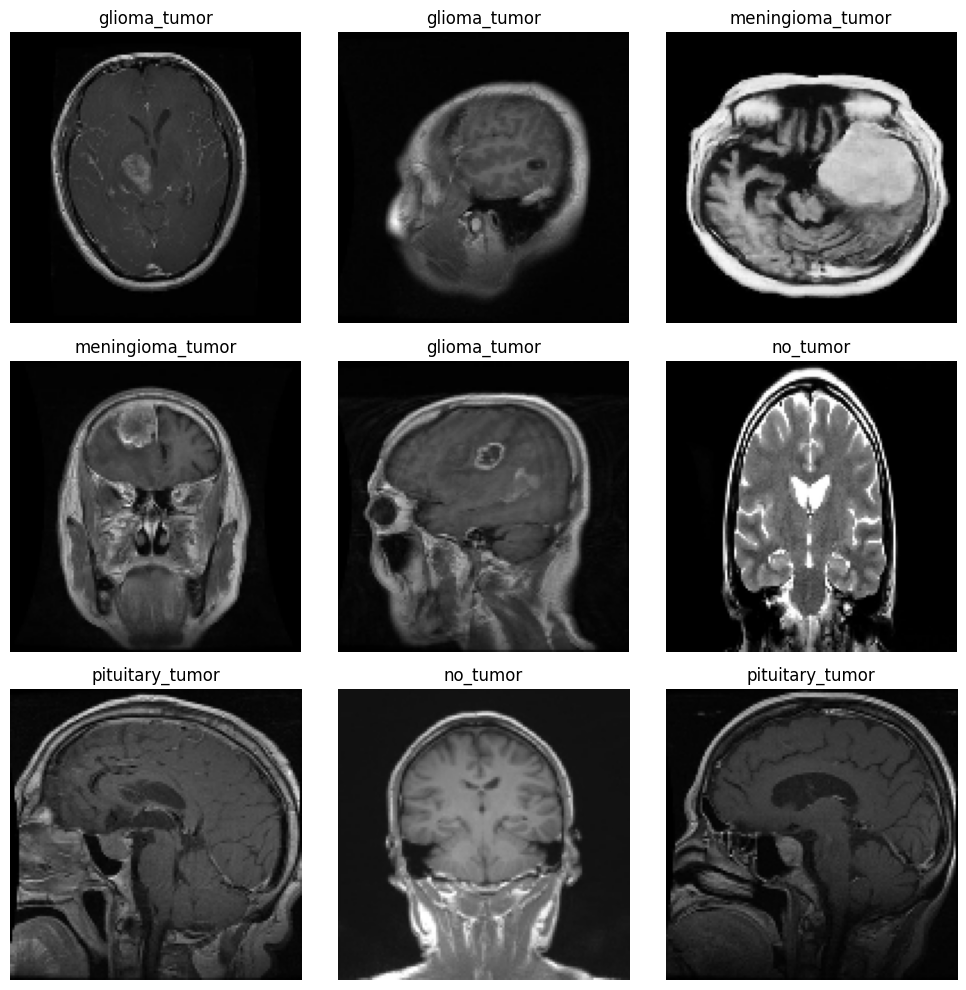

In [20]:
import matplotlib.pyplot as plt
import numpy as np

images, labels = next(train_generator)

plt.figure(figsize=(10, 10))

for i in range(9):
    plt.subplot(3, 3, i + 1)

    plt.imshow(images[i])

    class_index = np.argmax(labels[i])
    class_name = list(train_generator.class_indices.keys())[class_index]

    plt.title(class_name)
    plt.axis("off")

plt.tight_layout()
plt.show()

In [21]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D
from tensorflow.keras.layers import Flatten, Dense, Dropout

model = Sequential([
    # First convolutional block
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    # Second convolutional block
    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Third convolutional block
    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    # Classification layers
    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    # 4 output classes
    Dense(4, activation="softmax")
])

model.summary()

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           516 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,305,156 (12.61 MB)

 Trainable params: 3,305,156 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

In [22]:
model.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model compiled successfully!")

Model compiled successfully!


In [23]:
history = model.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 108s 1s/step - accuracy: 0.5606 - loss: 1.0036 - val_accuracy: 0.3401 - val_loss: 2.3123
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.7244 - loss: 0.6494 - val_accuracy: 0.5076 - val_loss: 2.2465
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 104s 1s/step - accuracy: 0.7986 - loss: 0.4872 - val_accuracy: 0.4898 - val_loss: 3.0351
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 105s 1s/step - accuracy: 0.8366 - loss: 0.3874 - val_accuracy: 0.6091 - val_loss: 2.1621
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.8854 - loss: 0.2974 - val_accuracy: 0.6726 - val_loss: 2.4883
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 106s 1s/step - accuracy: 0.9150 - loss: 0.2312 - val_accuracy: 0.6726 - val_loss: 2.8169
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9362 - loss: 0.1660 - val_accuracy: 0.6980 - val_loss: 2.8534
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 103s 1s/step - accuracy: 0.9418 - loss: 0.1564 - val_accuracy: 0.7005 - v

In [24]:
test_loss, test_accuracy = model.evaluate(test_generator)

print("Test Loss:", test_loss)
print("Test Accuracy:", test_accuracy)

13/13 ━━━━━━━━━━━━━━━━━━━━ 4s 283ms/step - accuracy: 0.7208 - loss: 4.1826
Test Loss: 4.182626247406006
Test Accuracy: 0.720812201499939


In [25]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

augmented_train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=15,
    width_shift_range=0.1,
    height_shift_range=0.1,
    zoom_range=0.1,
    horizontal_flip=True
)

augmented_train_generator = augmented_train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

print("Augmented training generator created successfully!")

Found 2870 images belonging to 4 classes.
Augmented training generator created successfully!


In [26]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense, Dropout

model2 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),
    Dense(4, activation="softmax")
])

model2.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 2 created and compiled successfully!")

Model 2 created and compiled successfully!


In [27]:
history2 = model2.fit(
    augmented_train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.4390 - loss: 1.2195 - val_accuracy: 0.2766 - val_loss: 1.8614
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.5669 - loss: 0.9846 - val_accuracy: 0.3096 - val_loss: 1.8447
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.6338 - loss: 0.8478 - val_accuracy: 0.3629 - val_loss: 3.0518
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 118s 1s/step - accuracy: 0.6746 - loss: 0.7731 - val_accuracy: 0.3706 - val_loss: 2.4573
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.6990 - loss: 0.7262 - val_accuracy: 0.3756 - val_loss: 2.5928
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 115s 1s/step - accuracy: 0.7150 - loss: 0.6808 - val_accuracy: 0.4036 - val_loss: 3.4961
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 123s 1s/step - accuracy: 0.7216 - loss: 0.6606 - val_accuracy: 0.3934 - val_loss: 3.6970
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 116s 1s/step - accuracy: 0.7300 - loss: 0.6385 - val_accuracy: 0.4442 - v

In [28]:
test_loss2, test_accuracy2 = model2.evaluate(test_generator)

print("Model 2 Test Loss:", test_loss2)
print("Model 2 Test Accuracy:", test_accuracy2)


13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 454ms/step - accuracy: 0.4188 - loss: 3.9323
Model 2 Test Loss: 3.932307720184326
Model 2 Test Accuracy: 0.41878172755241394


In [29]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

model3 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(4, activation="softmax")
])

model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 3 created and compiled successfully!")


Model 3 created and compiled successfully!


In [30]:
history3 = model3.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 160s 2s/step - accuracy: 0.6826 - loss: 0.8933 - val_accuracy: 0.1878 - val_loss: 3.0826
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.8118 - loss: 0.5225 - val_accuracy: 0.2030 - val_loss: 3.4324
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 158s 2s/step - accuracy: 0.8317 - loss: 0.4575 - val_accuracy: 0.3579 - val_loss: 4.0435
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.8906 - loss: 0.3043 - val_accuracy: 0.3376 - val_loss: 2.5487
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.9073 - loss: 0.2629 - val_accuracy: 0.5025 - val_loss: 1.7482
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 164s 2s/step - accuracy: 0.9436 - loss: 0.1707 - val_accuracy: 0.7132 - val_loss: 1.6504
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.9686 - loss: 0.1061 - val_accuracy: 0.6980 - val_loss: 1.1649
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 205s 2s/step - accuracy: 0.9774 - loss: 0.0689 - val_accuracy: 0.7766 - v

In [31]:
test_loss3, test_accuracy3 = model3.evaluate(test_generator)

print("Model 3 Test Loss:", test_loss3)
print("Model 3 Test Accuracy:", test_accuracy3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 6s 457ms/step - accuracy: 0.7792 - loss: 1.4353
Model 3 Test Loss: 1.4353089332580566
Model 3 Test Accuracy: 0.779187798500061


In [32]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

model4 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(4, activation="softmax")
])

model4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 4 created and compiled successfully!")

Model 4 created and compiled successfully!


In [ ]:
history4 = model4.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

In [2]:
!pip -q install kaggle

from google.colab import files
files.upload()

Saving kaggle.json to kaggle.json


{'kaggle.json': b'{"username":"prayanv","key":"03ed93932c816a15a29b6a5e3ed84391"}'}

In [3]:
!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json

print("Kaggle configured successfully!")


Kaggle configured successfully!


In [9]:
!rm -rf /content/brain_tumor_dataset
!mkdir -p /content/brain_tumor_dataset

!unzip -q /content/brain-tumor-mri-dataset.zip -d /content/brain_tumor_dataset

print("Dataset extracted successfully!")

Dataset extracted successfully!


In [10]:
!kaggle datasets download -d bilalakgz/brain-tumor-mri-dataset -p /content

print("Dataset download completed!")

Dataset URL: https://www.kaggle.com/datasets/bilalakgz/brain-tumor-mri-dataset
License(s): MIT
brain-tumor-mri-dataset.zip: Skipping, found more recently modified local copy (use --force to force download)
Dataset download completed!


In [12]:
train_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Training"
test_path = "/content/brain_tumor_dataset/brain_tumor_dataset/brain_tumor_classification/Testing"

import os

print("Training path exists:", os.path.exists(train_path))
print("Testing path exists:", os.path.exists(test_path))

Training path exists: True
Testing path exists: True


In [13]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

IMG_SIZE = (128, 128)
BATCH_SIZE = 32

train_datagen = ImageDataGenerator(
    rescale=1./255
)

test_datagen = ImageDataGenerator(
    rescale=1./255
)

train_generator = train_datagen.flow_from_directory(
    train_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=True
)

test_generator = test_datagen.flow_from_directory(
    test_path,
    target_size=IMG_SIZE,
    batch_size=BATCH_SIZE,
    class_mode="categorical",
    shuffle=False
)

Found 2870 images belonging to 4 classes.
Found 394 images belonging to 4 classes.


In [14]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

model4 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(256, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    Dropout(0.5),

    Dense(4, activation="softmax")
])

model4.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 4 created and compiled successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 4 created and compiled successfully!


In [15]:
history4 = model4.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 176s 2s/step - accuracy: 0.6045 - loss: 1.3385 - val_accuracy: 0.1878 - val_loss: 6.6835
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.6794 - loss: 0.7443 - val_accuracy: 0.1878 - val_loss: 16.1570
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 171s 2s/step - accuracy: 0.7199 - loss: 0.6439 - val_accuracy: 0.3071 - val_loss: 6.8181
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.7362 - loss: 0.6218 - val_accuracy: 0.3934 - val_loss: 3.2487
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 168s 2s/step - accuracy: 0.7617 - loss: 0.5348 - val_accuracy: 0.5076 - val_loss: 2.1746
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 170s 2s/step - accuracy: 0.8077 - loss: 0.4830 - val_accuracy: 0.4898 - val_loss: 3.9851
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 169s 2s/step - accuracy: 0.8345 - loss: 0.4037 - val_accuracy: 0.4772 - val_loss: 3.7431
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 167s 2s/step - accuracy: 0.8334 - loss: 0.4070 - val_accuracy: 0.5711 - 

In [16]:
test_loss4, test_accuracy4 = model4.evaluate(test_generator)

print("Model 4 Test Loss:", test_loss4)
print("Model 4 Test Accuracy:", test_accuracy4)

13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 539ms/step - accuracy: 0.5660 - loss: 4.2071
Model 4 Test Loss: 4.2071027755737305
Model 4 Test Accuracy: 0.5659898519515991


In [17]:
import pandas as pd

results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "CNN + Data Augmentation",
        "CNN + Batch Normalization",
        "Deeper CNN"
    ],
    "Test Accuracy (%)": [
        72.08,
        41.88,
        77.92,
        56.60
    ]
})

results

,Model,Test Accuracy (%)
0,Basic CNN,72.08
1,CNN + Data Augmentation,41.88
2,CNN + Batch Normalization,77.92
3,Deeper CNN,56.60


In [18]:
results.to_csv("/content/model_comparison.csv", index=False)

print("Model comparison saved successfully!")

Model comparison saved successfully!


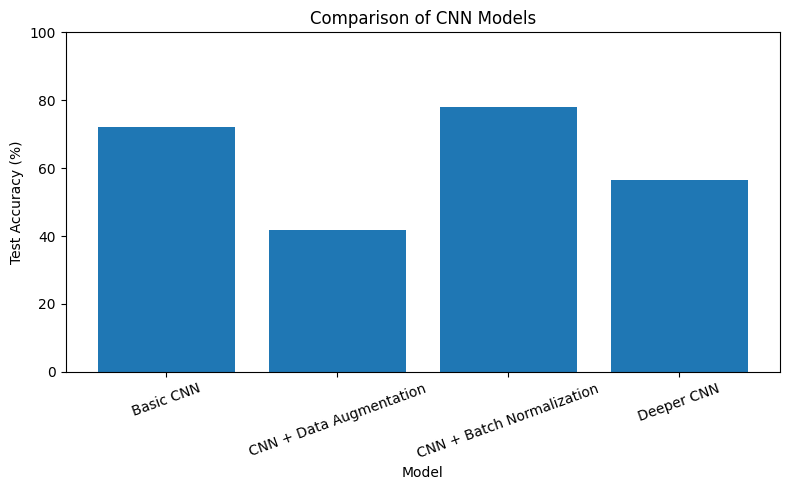

In [19]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 5))

plt.bar(results["Model"], results["Test Accuracy (%)"])

plt.title("Comparison of CNN Models")
plt.xlabel("Model")
plt.ylabel("Test Accuracy (%)")
plt.ylim(0, 100)

plt.xticks(rotation=20)
plt.tight_layout()
plt.show()

In [21]:
model4.save("/content/brain_tumor_model4.keras")

print("Model 4 saved successfully!")

Model 4 saved successfully!


In [22]:
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix

test_generator.reset()

predictions = model4.predict(test_generator)
y_pred = np.argmax(predictions, axis=1)
y_true = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(y_true, y_pred, target_names=class_names))

13/13 ━━━━━━━━━━━━━━━━━━━━ 10s 703ms/step
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.14      0.25       100
meningioma_tumor       0.43      0.97      0.59       115
        no_tumor       0.80      0.58      0.67       105
 pituitary_tumor       0.88      0.49      0.63        74

        accuracy                           0.57       394
       macro avg       0.78      0.55      0.53       394
    weighted avg       0.76      0.57      0.53       394



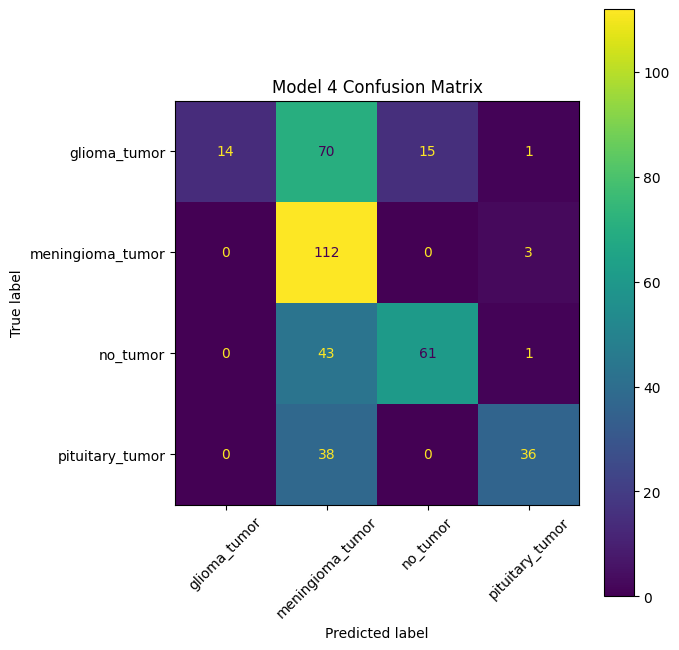

In [23]:
import matplotlib.pyplot as plt
from sklearn.metrics import ConfusionMatrixDisplay

cm = confusion_matrix(y_true, y_pred)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))
disp.plot(ax=ax, xticks_rotation=45)

plt.title("Model 4 Confusion Matrix")
plt.tight_layout()
plt.show()

In [24]:
from tensorflow.keras import Sequential
from tensorflow.keras.layers import (
    Conv2D, MaxPooling2D, Flatten, Dense, Dropout, BatchNormalization
)

model3 = Sequential([
    Conv2D(32, (3, 3), activation="relu", input_shape=(128, 128, 3)),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(64, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Conv2D(128, (3, 3), activation="relu"),
    BatchNormalization(),
    MaxPooling2D((2, 2)),

    Flatten(),
    Dense(128, activation="relu"),
    BatchNormalization(),
    Dropout(0.5),

    Dense(4, activation="softmax")
])

model3.compile(
    optimizer="adam",
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("Model 3 rebuilt and compiled successfully!")

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model 3 rebuilt and compiled successfully!


In [25]:
history3 = model3.fit(
    train_generator,
    epochs=10,
    validation_data=test_generator
)

Epoch 1/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 165s 2s/step - accuracy: 0.6638 - loss: 1.0010 - val_accuracy: 0.2234 - val_loss: 3.8704
Epoch 2/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 159s 2s/step - accuracy: 0.7948 - loss: 0.5636 - val_accuracy: 0.2513 - val_loss: 3.1996
Epoch 3/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8634 - loss: 0.3802 - val_accuracy: 0.3325 - val_loss: 2.2745
Epoch 4/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 157s 2s/step - accuracy: 0.8815 - loss: 0.3235 - val_accuracy: 0.5203 - val_loss: 2.0448
Epoch 5/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 156s 2s/step - accuracy: 0.9209 - loss: 0.2321 - val_accuracy: 0.4746 - val_loss: 2.1825
Epoch 6/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9540 - loss: 0.1406 - val_accuracy: 0.4492 - val_loss: 2.1553
Epoch 7/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 162s 2s/step - accuracy: 0.9502 - loss: 0.1463 - val_accuracy: 0.5330 - val_loss: 2.8586
Epoch 8/10
90/90 ━━━━━━━━━━━━━━━━━━━━ 155s 2s/step - accuracy: 0.9561 - loss: 0.1327 - val_accuracy: 0.7766 - v

In [26]:
test_generator.reset()

test_loss3, test_accuracy3 = model3.evaluate(test_generator)

print("Model 3 Test Loss:", test_loss3)
print("Model 3 Test Accuracy:", test_accuracy3)

13/13 ━━━━━━━━━━━━━━━━━━━━ 8s 605ms/step - accuracy: 0.7107 - loss: 1.8827
Model 3 Test Loss: 1.8827065229415894
Model 3 Test Accuracy: 0.710659921169281


In [27]:
model3.save("/content/brain_tumor_model3.keras")

print("Model 3 saved successfully!")

Model 3 saved successfully!


In [28]:
model3_results = pd.DataFrame({
    "Model": ["CNN + Batch Normalization"],
    "Test Accuracy (%)": [test_accuracy3 * 100],
    "Test Loss": [test_loss3]
})

model3_results.to_csv("/content/model3_results.csv", index=False)

print("Model 3 results saved successfully!")

Model 3 results saved successfully!


In [30]:
test_generator.reset()

predictions3 = model3.predict(test_generator)
y_pred3 = np.argmax(predictions3, axis=1)
y_true3 = test_generator.classes

class_names = list(test_generator.class_indices.keys())

print(classification_report(
    y_true3,
    y_pred3,
    target_names=class_names
))

13/13 ━━━━━━━━━━━━━━━━━━━━ 5s 371ms/step
                  precision    recall  f1-score   support

    glioma_tumor       1.00      0.17      0.29       100
meningioma_tumor       0.84      0.76      0.80       115
        no_tumor       0.58      1.00      0.74       105
 pituitary_tumor       0.76      0.96      0.85        74

        accuracy                           0.71       394
       macro avg       0.80      0.72      0.67       394
    weighted avg       0.80      0.71      0.66       394



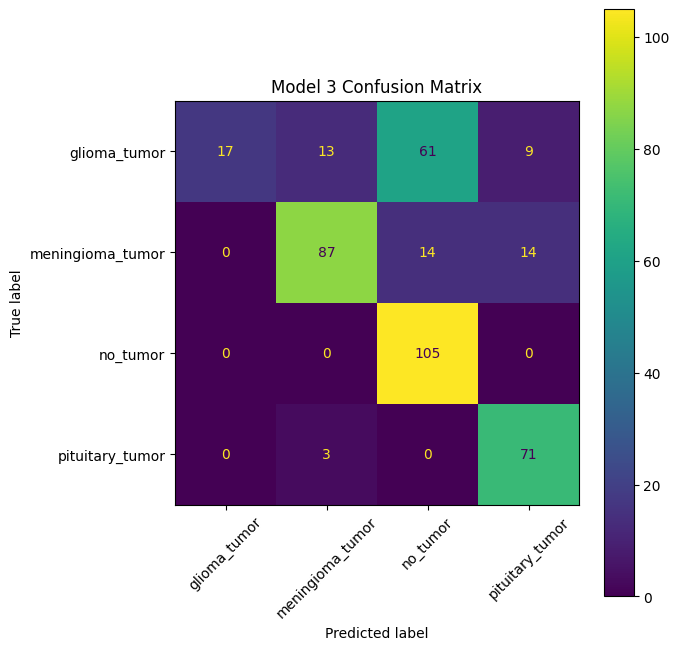

In [31]:
cm3 = confusion_matrix(y_true3, y_pred3)

disp3 = ConfusionMatrixDisplay(
    confusion_matrix=cm3,
    display_labels=class_names
)

fig, ax = plt.subplots(figsize=(7, 7))
disp3.plot(ax=ax, xticks_rotation=45)

plt.title("Model 3 Confusion Matrix")
plt.tight_layout()
plt.show()

In [32]:
final_results = pd.DataFrame({
    "Model": [
        "Basic CNN",
        "CNN + Data Augmentation",
        "CNN + Batch Normalization",
        "Deeper CNN"
    ],
    "Test Accuracy (%)": [
        72.08,
        41.88,
        71.07,
        56.60
    ]
})

final_results


,Model,Test Accuracy (%)
0,Basic CNN,72.08
1,CNN + Data Augmentation,41.88
2,CNN + Batch Normalization,71.07
3,Deeper CNN,56.60


In [33]:
final_results.to_csv("/content/final_model_comparison.csv", index=False)

print("Final model comparison saved successfully!")

Final model comparison saved successfully!


In [34]:
import os

print("Training images:")
for class_name in sorted(os.listdir(train_path)):
    class_dir = os.path.join(train_path, class_name)
    if os.path.isdir(class_dir):
        print(class_name, ":", len(os.listdir(class_dir)))

print("\nTesting images:")
for class_name in sorted(os.listdir(test_path)):
    class_dir = os.path.join(test_path, class_name)
    if os.path.isdir(class_dir):
        print(class_name, ":", len(os.listdir(class_dir)))

Training images:
glioma_tumor : 826
meningioma_tumor : 822
no_tumor : 395
pituitary_tumor : 827

Testing images:
glioma_tumor : 100
meningioma_tumor : 115
no_tumor : 105
pituitary_tumor : 74
